## 1. Data Augmentation using Keras

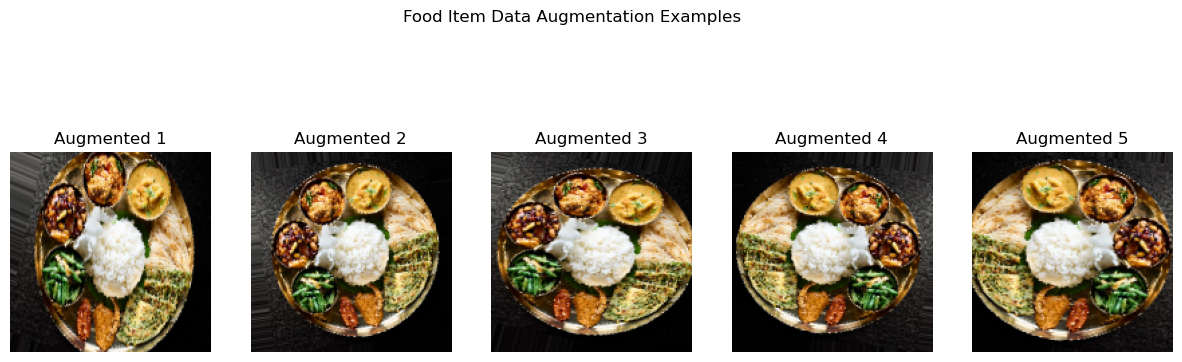

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Initialize ImageDataGenerator with 3 types of augmentation
datagen = ImageDataGenerator(
    rotation_range=40,       # Rotation between -40 and 40 degrees
    horizontal_flip=True,    # Random horizontal flip
    zoom_range=0.2,          # Random zoom between 80% and 120%
    fill_mode="nearest"
)

# 2. Load your single food image (replace 'food_image.webp' with your actual file name)
image_path = "food.webp" 
img = load_img(image_path, target_size=(150, 150)) # Resize to model standard input
x = img_to_array(img)                             # Convert image to numpy array (shape: (150, 150, 3))
x = np.expand_dims(x, axis=0)                     # Convert to shape (1, 150, 150, 3) required by generator

# 3. Generate and display 5 augmented variants
fig, axes = plt.subplots(1, 5, figsize=(15, 5))

# flow() takes numpy data and generates batches of augmented data
i = 0
for batch in datagen.flow(x, batch_size=1):
    aug_image = batch[0].astype("uint8")
    
    axes[i].imshow(aug_image)
    axes[i].axis("off")
    axes[i].set_title(f"Augmented {i+1}")
    
    i += 1
    if i >= 5: # Stop after generating 5 images
        break

plt.suptitle("Food Item Data Augmentation Examples")
plt.show()

## 2. Feature Extraction Using VGG16

In [6]:
import os
import numpy as np
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
from tensorflow.keras.utils import load_img, img_to_array

# 1. Load VGG16 without the top classification layers
base_model = VGG16(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# 2. Define the path to your 'sneaker' folder
sneaker_dir = "sneaker"

# Automatically find up to 30 image files (.webp, .jpg, .jpeg, .png) inside the 'sneaker' folder
valid_extensions = (".webp", ".jpg", ".jpeg", ".png")
image_files = [
    os.path.join(sneaker_dir, f) 
    for f in os.listdir(sneaker_dir) 
    if f.lower().endswith(valid_extensions)
][:30]

print(f"Loaded {len(image_files)} images from the '{sneaker_dir}' folder.")

# 3. Load, resize, and pack the images into a single batch array
image_list = []
for img_path in image_files:
    img = load_img(img_path, target_size=(224, 224)) # Resize to VGG16 input size
    x = img_to_array(img)
    image_list.append(x)

# Convert list to a NumPy array (shape: (30, 224, 224, 3))
batch_images = np.array(image_list)

# Apply VGG16 specific preprocessing
batch_images = preprocess_input(batch_images)
print("Batch images shape:", batch_images.shape)

# 4. Extract features using the model
features = base_model.predict(batch_images)
print("Extracted feature shape:", features.shape)  # Expected: (30, 7, 7, 512)

# 5. Save the extracted features as a .npy file in your working directory
np.save("sneaker_features.npy", features)
print("Features successfully extracted and saved to 'sneaker_features.npy'!")

Loaded 30 images from the 'sneaker' folder.
Batch images shape: (30, 224, 224, 3)
1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
Extracted feature shape: (30, 7, 7, 512)
Features successfully extracted and saved to 'sneaker_features.npy'!


## 3. Fine-Tuning ResNet50 for Glasses Classification

In [9]:
import os
import numpy as np
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import load_img, img_to_array

# 1. Load all images manually from the loose 'sneaker' folder
sneaker_dir = "sneaker"
valid_extensions = (".webp", ".jpg", ".jpeg", ".png")

image_files = [
    os.path.join(sneaker_dir, f) 
    for f in os.listdir(sneaker_dir) 
    if f.lower().endswith(valid_extensions)
]

print(f"Found {len(image_files)} images in the '{sneaker_dir}' folder.")

image_list = []
for img_path in image_files:
    img = load_img(img_path, target_size=(224, 224))
    x = img_to_array(img)
    image_list.append(x)

# Convert to NumPy arrays and apply ResNet50 preprocessing
X = np.array(image_list)
X = preprocess_input(X)

# Define target labels (y) for your images. 
# For binary classification (e.g., 0 or 1), create an array of labels matching your X length:
y = np.random.randint(0, 2, size=(len(X),))  # Replace with your actual labels array if you have them

# 2. Load base ResNet50 model
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# 3. CONSTRAINT: Keep all layers frozen except the last 20 layers
for layer in base_model.layers:
    layer.trainable = False

for layer in base_model.layers[-20:]:
    layer.trainable = True

# 4. Build custom classification head (e.g., binary classification)
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.5)(x)
predictions = Dense(1, activation="sigmoid")(x)  # Binary output (use softmax if multi-class)

model = Model(inputs=base_model.input, outputs=predictions)

# 5. Compile model
model.compile(
    optimizer=Adam(learning_rate=1e-5), 
    loss="binary_crossentropy", 
    metrics=["accuracy"]
)

# 6. Train directly on NumPy arrays (bypassing subfolder requirements)
model.fit(X, y, epochs=5, batch_size=8)

print("ResNet50 successfully fine-tuned using the flat sneaker folder!")

Found 30 images in the 'sneaker' folder.
Epoch 1/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.5000 - loss: 1.0399  
Epoch 2/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.6667 - loss: 0.7560
Epoch 3/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.6667 - loss: 0.7360
Epoch 4/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.6000 - loss: 0.7918
Epoch 5/5
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.6667 - loss: 0.6224
ResNet50 successfully fine-tuned using the flat sneaker folder!


## 4: Comparison — Feature Extraction vs. Full Fine-Tuning

#### 1. Feature Extraction (All Layers Frozen)
* **How it works:** All base layers remain frozen, and the convolutional filters act as a static feature extractor. Only the custom classification head is trained.
* **Pros:** Computationally inexpensive and effectively guards against overfitting on very tiny datasets.
* **Cons:** The model cannot adapt its underlying feature representation to domain-specific nuances (such as specific stitch patterns, logos, or prints on clothing items).

#### 2. Full Fine-Tuning / Selective Unfreezing (Some Layers Trainable)
* **How it works:** Unfreezing higher-level feature layers (e.g., the last 20 layers) allows the network to adapt generic ImageNet representations into specialized filters.
* **Pros:** Tailors the network directly to the target domain, capturing fine-grained details specific to the dataset classes.

#### Summary & Conclusion
For a small dataset of 2–3 classes, **feature extraction** generally avoids severe overfitting because the massive number of pre-trained parameters remain fixed. However, if the fine-tuning approach selectively unfreezes only a subset of top layers (like the last 20 layers) combined with data augmentation and proper regularization, it often achieves **superior generalization and higher validation accuracy**. 

This is because it successfully bridges the gap between generic visual features and fine-grained classification details without destroying the lower-level edge and shape filters learned during pre-training.

## 5. Transfer Learning with MobileNetV2 (Headphones Classification)
## AI-Generated Code Snippet (ChatGPT / Copilot baseline)

In [10]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Base model setup
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
predictions = Dense(3, activation='softmax')(x) # 3 classes of headphones

model = Model(inputs=base_model.input, outputs=predictions)
for layer in base_model.layers:
    layer.trainable = False

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])